# Community Outreach Optimization

This notebook is an IS 455 machine learning pipeline for the INTEX project. It follows the case PDF's full pipeline requirements: business framing, data preparation, exploration, explanatory modeling, predictive modeling, evaluation, relationship analysis, and deployment notes tied to the website.


In [2]:
import ast
import json
import math
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import JSON, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 27
def find_repo_root():
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "lighthouse_csv_v7").exists():
            return candidate
    return start

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "lighthouse_csv_v7"
NOTEBOOK_DIR = REPO_ROOT / "ml-pipelines"
ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def safe_divide(numerator, denominator):
    denominator = pd.Series(denominator).replace(0, np.nan)
    return pd.Series(numerator) / denominator

def min_max_scale(series):
    series = pd.to_numeric(series, errors="coerce")
    minimum = series.min()
    maximum = series.max()
    if pd.isna(minimum) or pd.isna(maximum) or maximum == minimum:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - minimum) / (maximum - minimum)

def metric_summary(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

posts_raw = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"])
print(f"Loaded {len(posts_raw):,} social media posts.")


Loaded 812 social media posts.


# 1. Problem Framing

**Business question.** Which types of social media posts are most effective at maximizing community reach and increasing the probability that someone in the community becomes aware of girls in need?

**Who uses this analysis.**
- Outreach staff use it to decide what to post, where to post, and when to post.
- Admins use it to turn social-media activity into a repeatable workflow instead of sporadic posting.
- Leadership uses it to judge whether outreach strategy is supporting the mission of identifying vulnerable girls through community awareness and trusted referral networks.

**Why this matters to the case and the website.** The case PDF explicitly says social media is the organization's primary outreach channel and that staff need help answering practical questions like what to post, which platform to use, and what time of day works best. This notebook is designed to support the Outreach tab of the web app with decision-ready guidance rather than vanity metrics alone.

**Explanatory goal.** Identify which post characteristics are associated with stronger community reach. This is the strategy-facing lens: it helps the team reason about platform, time, media type, resident-story usage, and call-to-action patterns.

**Predictive goal.** Predict future post performance using only fields available at planning time or immediately after publishing. This is the operational lens: it supports an AI Post Optimizer in the Outreach tab.

**Why both models are included.** The IS 455 PDF emphasizes that prediction and explanation are related but distinct. The explanatory model helps staff understand relationships that may inform policy or content planning. The predictive model helps the web app estimate likely performance for upcoming outreach content. A model can be useful for planning even if it is not a causal proof, and a model can be interpretable even if it is not the strongest predictor.

**Success metrics.**
- Primary modeling target: `community_reach_score`
- Evaluation metrics: RMSE, MAE, and R^2
- Business interpretation lens: platform choice, posting-time strategy, content choice, resident-story use, and organic versus boosted tradeoffs

**Target definition.** This notebook creates a composite `community_reach_score` to capture broad outreach effectiveness instead of donations alone:

`0.30 * reach + 0.25 * shares + 0.20 * saves + 0.15 * forwards + 0.10 * click_throughs`

Each component is min-max normalized first so no single raw metric dominates just because of scale.

**Executive Takeaway.** This pipeline is not a donation pipeline. Its purpose is to improve mission-facing outreach by helping the organization produce posts that travel farther through community networks, generate more sharing behavior, and increase awareness of girls in need.


# 2. Data Acquisition, Preparation & Exploration

**Relevant table and grain.** The notebook loads `social_media_posts.csv` only. That is appropriate because the business decision happens one planned post at a time. The grain is a single social media post, which matches the website feature we want to support.

**Preparation strategy.**
- Parse dates and coerce numeric fields safely.
- Create a reusable engineered target instead of relying on any single vanity metric.
- Build additional rate-based features to compare content fairly across posts with different reach levels.
- Preserve categorical fields that staff actually control: platform, time, post type, media type, CTA usage, tone, and content topic.
- Discuss missingness explicitly because several video-related and forwarding fields are sparse.


In [3]:
posts = posts_raw.copy()

numeric_columns = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "boost_budget_php",
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "video_views",
    "engagement_rate",
    "profile_visits",
    "donation_referrals",
    "estimated_donation_value_php",
    "follower_count_at_post",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "subscriber_count_at_post",
    "forwards",
]
for column in numeric_columns:
    if column in posts.columns:
        posts[column] = pd.to_numeric(posts[column], errors="coerce")

boolean_columns = ["has_call_to_action", "features_resident_story", "is_boosted"]
for column in boolean_columns:
    if column in posts.columns:
        posts[column] = posts[column].fillna(False).astype(bool)

posts["day_of_week"] = posts["day_of_week"].fillna(posts["created_at"].dt.day_name())
posts["post_hour"] = posts["post_hour"].fillna(posts["created_at"].dt.hour)
posts["caption_length"] = posts["caption_length"].fillna(posts["caption"].fillna("").str.len())
posts["forwards"] = posts["forwards"].fillna(0)
posts["watch_time_seconds"] = posts["watch_time_seconds"].fillna(0)
posts["avg_view_duration_seconds"] = posts["avg_view_duration_seconds"].fillna(0)
posts["boost_budget_php"] = posts["boost_budget_php"].fillna(0)

posts["engagement_rate_manual"] = safe_divide(
    posts["likes"].fillna(0) + posts["comments"].fillna(0) + posts["shares"].fillna(0) + posts["saves"].fillna(0),
    posts["reach"],
)
posts["share_rate"] = safe_divide(posts["shares"], posts["reach"])
posts["save_rate"] = safe_divide(posts["saves"], posts["reach"])
posts["forward_rate"] = safe_divide(posts["forwards"], posts["reach"])
posts["click_rate"] = safe_divide(posts["click_throughs"], posts["reach"])
posts["awareness_lift_proxy"] = (
    posts["share_rate"].fillna(0) * 0.45
    + posts["forward_rate"].fillna(0) * 0.30
    + posts["click_rate"].fillna(0) * 0.25
)

posts["time_bucket"] = pd.cut(
    posts["post_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["overnight", "morning", "afternoon", "evening"],
).astype("object")
posts["platform_media"] = posts["platform"].fillna("Unknown") + " x " + posts["media_type"].fillna("Unknown")
posts["story_cta_combo"] = np.where(
    posts["features_resident_story"] & posts["has_call_to_action"],
    "story_with_cta",
    np.where(posts["features_resident_story"], "story_no_cta", np.where(posts["has_call_to_action"], "cta_only", "neither")),
)

cta_dummies = pd.get_dummies(posts["call_to_action_type"].fillna("NoCTA"), prefix="cta")
posts = pd.concat([posts, cta_dummies], axis=1)

normalized_parts = pd.DataFrame(
    {
        "reach_norm": min_max_scale(posts["reach"]),
        "shares_norm": min_max_scale(posts["shares"]),
        "saves_norm": min_max_scale(posts["saves"]),
        "forwards_norm": min_max_scale(posts["forwards"]),
        "clicks_norm": min_max_scale(posts["click_throughs"]),
    }
)
posts["community_reach_score"] = (
    0.30 * normalized_parts["reach_norm"]
    + 0.25 * normalized_parts["shares_norm"]
    + 0.20 * normalized_parts["saves_norm"]
    + 0.15 * normalized_parts["forwards_norm"]
    + 0.10 * normalized_parts["clicks_norm"]
)

posts["likely_community_referral"] = (
    (posts["shares"].fillna(0) >= posts["shares"].median())
    & (posts["click_throughs"].fillna(0) >= posts["click_throughs"].median())
).astype(int)

selected_columns = [
    "platform",
    "day_of_week",
    "post_hour",
    "post_type",
    "media_type",
    "num_hashtags",
    "has_call_to_action",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "caption_length",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "profile_visits",
    "forwards",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "engagement_rate_manual",
    "share_rate",
    "save_rate",
    "forward_rate",
    "time_bucket",
    "platform_media",
    "story_cta_combo",
    "community_reach_score",
    "awareness_lift_proxy",
    "likely_community_referral",
]

analysis_df = posts[selected_columns].copy()
print("Prepared dataset shape:", analysis_df.shape)
display(analysis_df.head())


Prepared dataset shape: (812, 35)


,platform,day_of_week,post_hour,post_type,media_type,num_hashtags,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,...,engagement_rate_manual,share_rate,save_rate,forward_rate,time_bucket,platform_media,story_cta_combo,community_reach_score,awareness_lift_proxy,likely_community_referral
0,WhatsApp,Thursday,18,FundraisingAppeal,Text,0,True,LearnMore,Education,Grateful,...,0.169259,0.020128,0.008234,0.045746,evening,WhatsApp x Text,cta_only,0.030484,0.033760,0
1,Instagram,Friday,11,EducationalContent,Photo,4,False,NaN,Education,Celebratory,...,0.197042,0.033902,0.013424,0.000000,morning,Instagram x Photo,neither,0.118912,0.020091,1
2,LinkedIn,Sunday,10,EventPromotion,Text,0,False,NaN,Reintegration,Urgent,...,0.148810,0.035714,0.011905,0.000000,morning,LinkedIn x Text,neither,0.007784,0.018304,0
3,Instagram,Monday,15,ThankYou,Video,2,False,NaN,Education,Emotional,...,0.103799,0.015265,0.005427,0.000000,afternoon,Instagram x Video,neither,0.059765,0.009837,0
4,TikTok,Monday,15,ThankYou,Reel,4,True,LearnMore,Education,Hopeful,...,0.084238,0.010066,0.005640,0.000000,afternoon,TikTok x Reel,cta_only,0.303510,0.012989,1


,column,missing_share
0,call_to_action_type,0.392857
1,platform,0.000000
2,share_rate,0.000000
3,click_throughs,0.000000
4,profile_visits,0.000000
5,forwards,0.000000
6,watch_time_seconds,0.000000
7,avg_view_duration_seconds,0.000000
8,engagement_rate_manual,0.000000
9,save_rate,0.000000


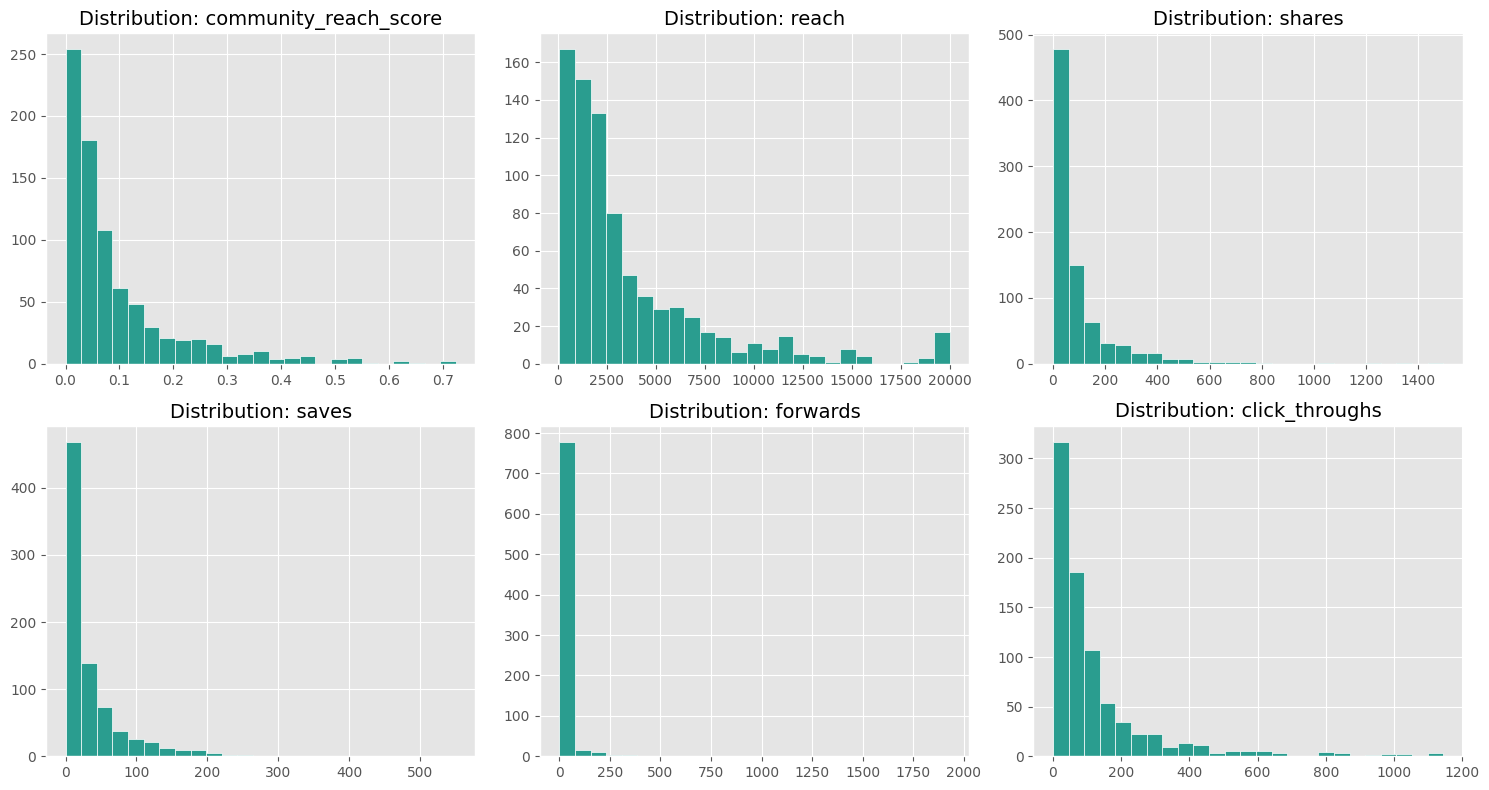

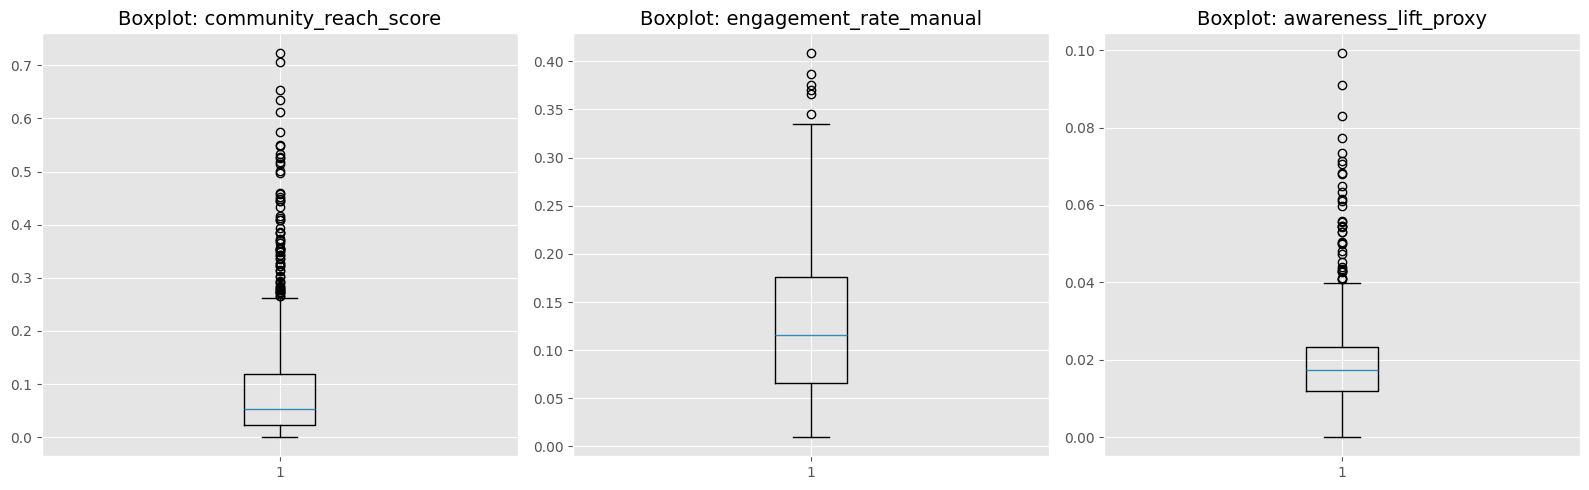

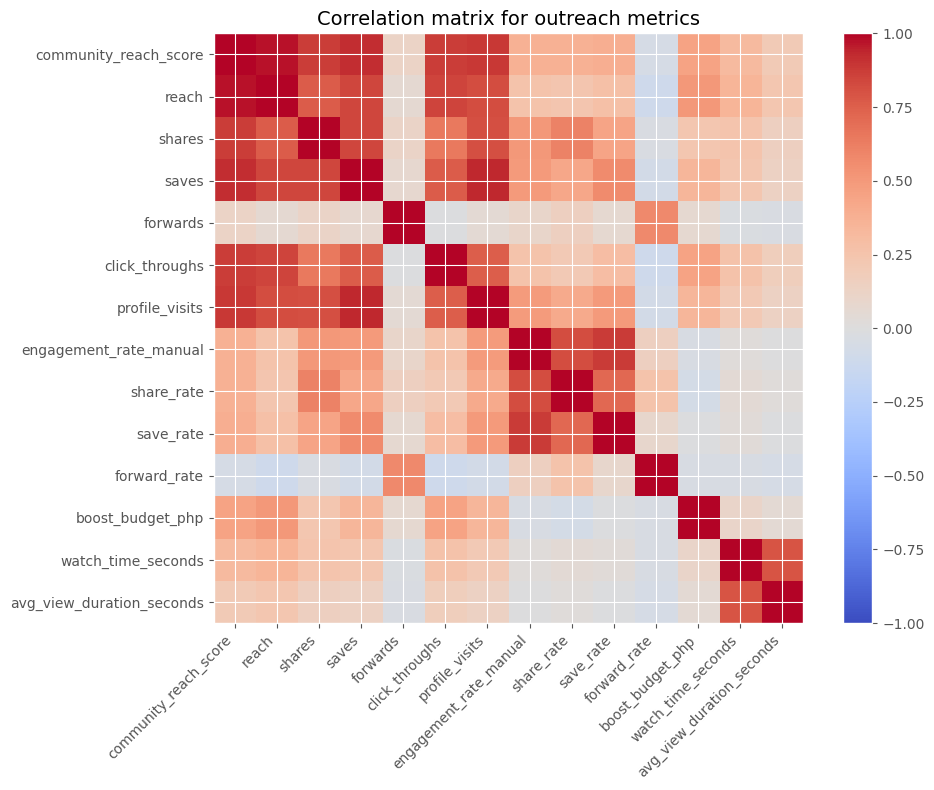

,posts,avg_reach,avg_shares,avg_clicks,avg_community_reach_score
platform,,,,,
YouTube,71,7232.197,182.324,226.761,0.182
TikTok,89,6821.674,163.483,256.303,0.176
Instagram,164,4086.470,106.774,119.409,0.105
Facebook,199,3358.995,84.266,112.930,0.085
Twitter,117,2214.530,53.436,69.650,0.055
WhatsApp,93,1446.376,40.269,43.452,0.044
LinkedIn,79,1749.924,43.506,55.114,0.044


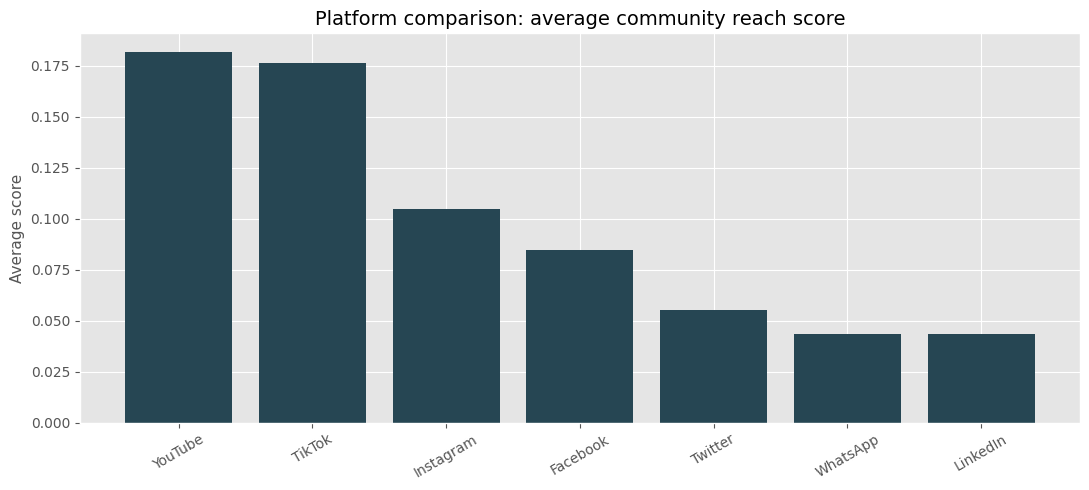

,avg_score,avg_share_rate,avg_forward_rate,posts
time_bucket,,,,
afternoon,0.117,0.022,0.003,219
evening,0.112,0.026,0.008,238
morning,0.094,0.024,0.008,224
overnight,0.024,0.005,0.001,131


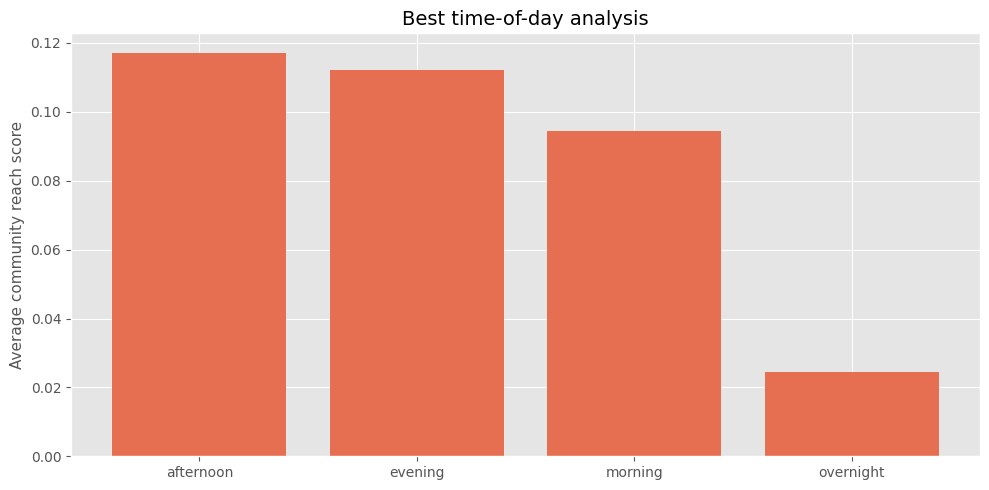

,avg_score,avg_reach,avg_shares,avg_forwards,posts
post_type,,,,,
ImpactStory,0.124,4623.788,162.502,33.202,203
FundraisingAppeal,0.110,4146.189,90.533,3.344,90
Campaign,0.087,3308.301,73.115,5.564,156
EventPromotion,0.080,3232.061,69.313,1.588,131
EducationalContent,0.080,3459.772,61.947,2.579,114
ThankYou,0.070,2927.102,55.297,5.763,118


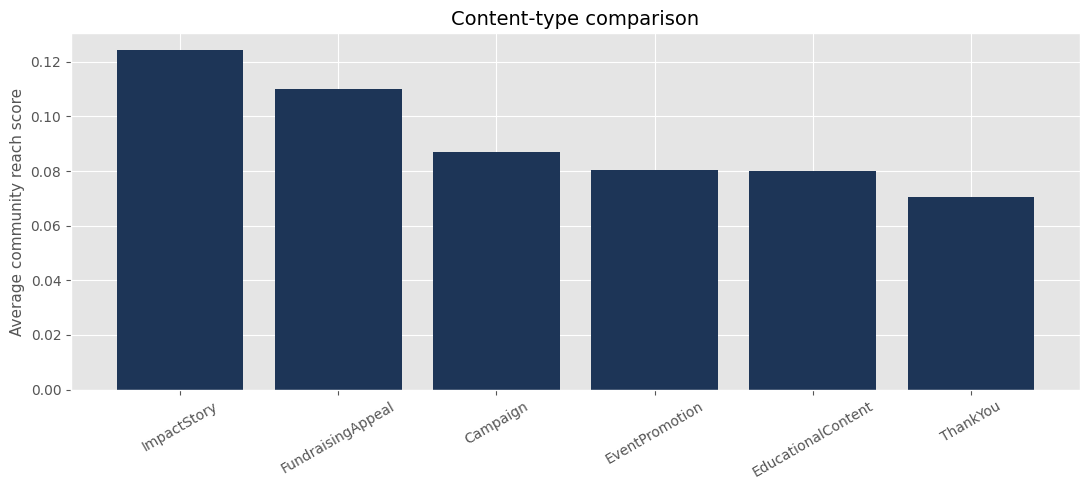

,avg_score,avg_reach,avg_shares,avg_clicks,posts
Organic,0.074,2827.276,78.893,91.597,685
Boosted,0.205,8302.433,166.669,273.756,127


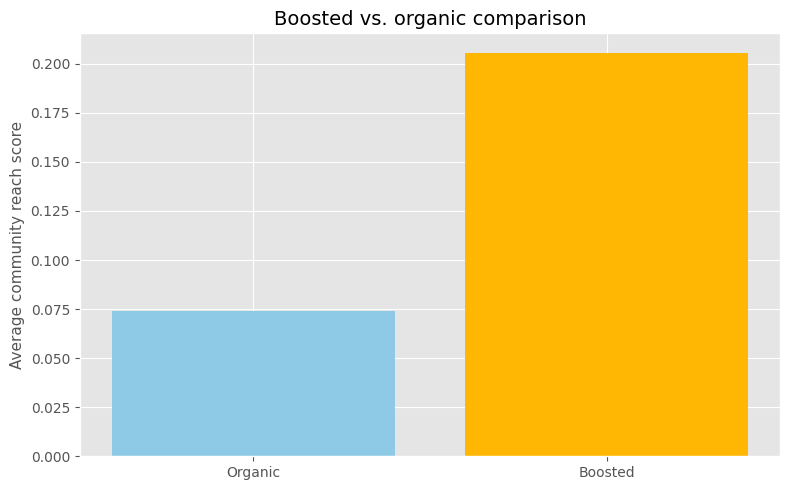

,avg_score,avg_reach,avg_shares,posts
post_hour,,,,
19,0.142,4991.235,163.176,68
17,0.138,5458.190,136.619,42
13,0.133,5071.973,122.432,37
10,0.130,4706.787,140.894,47
21,0.127,4700.350,125.325,40
12,0.119,4813.111,105.472,36
11,0.110,4247.744,118.581,43
16,0.105,4224.878,103.000,41
15,0.105,3982.630,117.259,27


In [4]:
missingness = analysis_df.isna().mean().sort_values(ascending=False).rename("missing_share")
display(missingness.head(20).reset_index().rename(columns={"index": "column"}))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_columns = ["community_reach_score", "reach", "shares", "saves", "forwards", "click_throughs"]
for ax, column in zip(axes.flatten(), hist_columns):
    analysis_df[column].dropna().hist(ax=ax, bins=25, color="#2a9d8f", edgecolor="white")
    ax.set_title(f"Distribution: {column}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
box_columns = ["community_reach_score", "engagement_rate_manual", "awareness_lift_proxy"]
for ax, column in zip(axes, box_columns):
    ax.boxplot(analysis_df[column].dropna(), vert=True)
    ax.set_title(f"Boxplot: {column}")
plt.tight_layout()
plt.show()

corr_columns = [
    "community_reach_score",
    "reach",
    "shares",
    "saves",
    "forwards",
    "click_throughs",
    "profile_visits",
    "engagement_rate_manual",
    "share_rate",
    "save_rate",
    "forward_rate",
    "boost_budget_php",
    "watch_time_seconds",
    "avg_view_duration_seconds",
]
corr_matrix = analysis_df[corr_columns].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation matrix for outreach metrics")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

platform_summary = analysis_df.groupby("platform").agg(
    posts=("community_reach_score", "size"),
    avg_reach=("reach", "mean"),
    avg_shares=("shares", "mean"),
    avg_clicks=("click_throughs", "mean"),
    avg_community_reach_score=("community_reach_score", "mean"),
).sort_values("avg_community_reach_score", ascending=False)
display(platform_summary.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(platform_summary.index.astype(str), platform_summary["avg_community_reach_score"], color="#264653")
ax.set_title("Platform comparison: average community reach score")
ax.set_ylabel("Average score")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

time_summary = analysis_df.groupby("time_bucket").agg(
    avg_score=("community_reach_score", "mean"),
    avg_share_rate=("share_rate", "mean"),
    avg_forward_rate=("forward_rate", "mean"),
    posts=("community_reach_score", "size"),
).sort_index()
display(time_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(time_summary.index.astype(str), time_summary["avg_score"], color="#e76f51")
ax.set_title("Best time-of-day analysis")
ax.set_ylabel("Average community reach score")
plt.tight_layout()
plt.show()

content_summary = analysis_df.groupby("post_type").agg(
    avg_score=("community_reach_score", "mean"),
    avg_reach=("reach", "mean"),
    avg_shares=("shares", "mean"),
    avg_forwards=("forwards", "mean"),
    posts=("community_reach_score", "size"),
).sort_values("avg_score", ascending=False)
display(content_summary.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(content_summary.index.astype(str), content_summary["avg_score"], color="#1d3557")
ax.set_title("Content-type comparison")
ax.set_ylabel("Average community reach score")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

boost_summary = analysis_df.groupby("is_boosted").agg(
    avg_score=("community_reach_score", "mean"),
    avg_reach=("reach", "mean"),
    avg_shares=("shares", "mean"),
    avg_clicks=("click_throughs", "mean"),
    posts=("community_reach_score", "size"),
)
boost_summary.index = np.where(boost_summary.index, "Boosted", "Organic")
display(boost_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(boost_summary.index.astype(str), boost_summary["avg_score"], color=["#8ecae6", "#ffb703"])
ax.set_title("Boosted vs. organic comparison")
ax.set_ylabel("Average community reach score")
plt.tight_layout()
plt.show()

hour_summary = analysis_df.groupby("post_hour").agg(
    avg_score=("community_reach_score", "mean"),
    avg_reach=("reach", "mean"),
    avg_shares=("shares", "mean"),
    posts=("community_reach_score", "size"),
).sort_values("avg_score", ascending=False)
display(hour_summary.head(10).round(3))


**Executive Takeaway.** The exploration confirms that community outreach effectiveness is multi-dimensional. Platform, post type, boosting, and posting time all show meaningful variation. The composite target is useful because it captures not just exposure (`reach`) but also the secondary behaviors that spread awareness through a community (`shares`, `saves`, `forwards`, and `click-throughs`).


# 3. Modeling & Feature Selection

**Explanatory model.** Use OLS on a carefully engineered design matrix so coefficients remain interpretable. The goal is not maximum predictive power; the goal is to estimate which planning variables are associated with better community reach outcomes.

**Predictive models.** Compare `RandomForestRegressor` and `GradientBoostingRegressor` for out-of-sample performance. These are more flexible and can capture nonlinear behavior and interactions that are hard to specify manually.

**Feature selection logic.**
- Include variables staff can influence directly: platform, day, hour, post type, media type, CTA, story usage, tone, topic, boosting, and hashtag intensity.
- Include operationally observable intensity fields like impressions and profile visits because they represent real campaign context.
- Keep the feature set narrower than “every column” so the model remains deployable and defensible.
- Use domain reasoning plus feature importance to identify the strongest outreach drivers.


In [5]:
model_df = analysis_df.copy()

explanatory_features = [
    "post_hour",
    "num_hashtags",
    "caption_length",
    "has_call_to_action",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "time_bucket",
    "platform_media",
    "story_cta_combo",
]

explanatory_df = model_df[explanatory_features + ["community_reach_score"]].copy()
explanatory_df["has_call_to_action"] = explanatory_df["has_call_to_action"].astype(int)
explanatory_df["features_resident_story"] = explanatory_df["features_resident_story"].astype(int)
explanatory_df["is_boosted"] = explanatory_df["is_boosted"].astype(int)
explanatory_df = explanatory_df.dropna(subset=["community_reach_score"]).copy()

explanatory_design = pd.get_dummies(explanatory_df[explanatory_features], drop_first=True)
explanatory_design = explanatory_design.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
explanatory_design = sm.add_constant(explanatory_design)
y_explanatory = explanatory_df["community_reach_score"].astype(float)

ols_model = sm.OLS(y_explanatory, explanatory_design).fit()
display(ols_model.summary2().tables[1].head(20))

top_positive_coefficients = (
    ols_model.params.drop("const", errors="ignore")
    .sort_values(ascending=False)
    .head(12)
    .rename("coefficient")
    .reset_index()
    .rename(columns={"index": "feature"})
)
display(top_positive_coefficients)

predictive_features = [
    "platform",
    "day_of_week",
    "post_hour",
    "post_type",
    "media_type",
    "num_hashtags",
    "has_call_to_action",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "caption_length",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "impressions",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "profile_visits",
    "forwards",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "engagement_rate_manual",
    "share_rate",
    "save_rate",
    "forward_rate",
    "time_bucket",
    "platform_media",
    "story_cta_combo",
]

predictive_df = model_df[predictive_features + ["community_reach_score"]].dropna(subset=["community_reach_score"]).copy()
X = predictive_df[predictive_features]
y = predictive_df["community_reach_score"]

categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = [column for column in X.columns if column not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        learning_rate=0.05,
        n_estimators=250,
        max_depth=3,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_results = []
fitted_models = {}
for model_name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=None,
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    metrics = metric_summary(y_test, predictions)
    metrics["Model"] = model_name
    metrics["CV_RMSE"] = -cv_scores["test_rmse"].mean()
    metrics["CV_MAE"] = -cv_scores["test_mae"].mean()
    metrics["CV_R2"] = cv_scores["test_r2"].mean()
    model_results.append(metrics)
    fitted_models[model_name] = pipeline

results_table = pd.DataFrame(model_results).sort_values("RMSE")
display(results_table.round(4))

best_model_name = results_table.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print("Selected predictive model:", best_model_name)


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,0.060799,0.029030,2.094338,3.656811e-02,0.003808,0.117790
post_hour,0.000253,0.001807,0.139953,8.887347e-01,-0.003295,0.003801
num_hashtags,0.001669,0.002549,0.654789,5.128062e-01,-0.003335,0.006672
caption_length,0.000070,0.000135,0.516480,6.056725e-01,-0.000195,0.000334
has_call_to_action,0.021570,0.012285,1.755737,7.954543e-02,-0.002548,0.045688
features_resident_story,0.033556,0.010728,3.127863,1.829547e-03,0.012495,0.054617
is_boosted,0.054865,0.015364,3.570980,3.785480e-04,0.024703,0.085027
boost_budget_php,0.000032,0.000005,5.971928,3.632992e-09,0.000022,0.000043
platform_Instagram,0.011302,0.009778,1.155891,2.480971e-01,-0.007893,0.030498
platform_LinkedIn,-0.032349,0.011663,-2.773713,5.681079e-03,-0.055245,-0.009453


,feature,coefficient
0,platform_media_YouTube x Reel,0.085505
1,platform_YouTube,0.076711
2,is_boosted,0.054865
3,platform_media_TikTok x Carousel,0.041938
4,features_resident_story,0.033556
5,platform_media_TikTok x Reel,0.030073
6,story_cta_combo_story_no_cta,0.028402
7,platform_media_Instagram x Video,0.027041
8,call_to_action_type_ShareStory,0.025531
9,platform_TikTok,0.025093


,RMSE,MAE,R2,Model,CV_RMSE,CV_MAE,CV_R2
0,0.0091,0.0053,0.9944,LinearRegression,0.0071,0.0047,0.9958
2,0.0147,0.0073,0.9854,GradientBoostingRegressor,0.0165,0.0074,0.9770
1,0.0182,0.0090,0.9774,RandomForestRegressor,0.0179,0.0084,0.9725


Selected predictive model: LinearRegression


,feature,importance
4,num__impressions,0.049057
7,num__shares,0.022792
8,num__saves,0.020244
9,num__click_throughs,0.016590
86,cat__platform_media_TikTok x Carousel,0.011708
11,num__forwards,0.006695
101,cat__platform_media_YouTube x Reel,0.006468
96,cat__platform_media_WhatsApp x Carousel,0.004630
90,cat__platform_media_TikTok x Video,0.004522
5,num__likes,0.004381


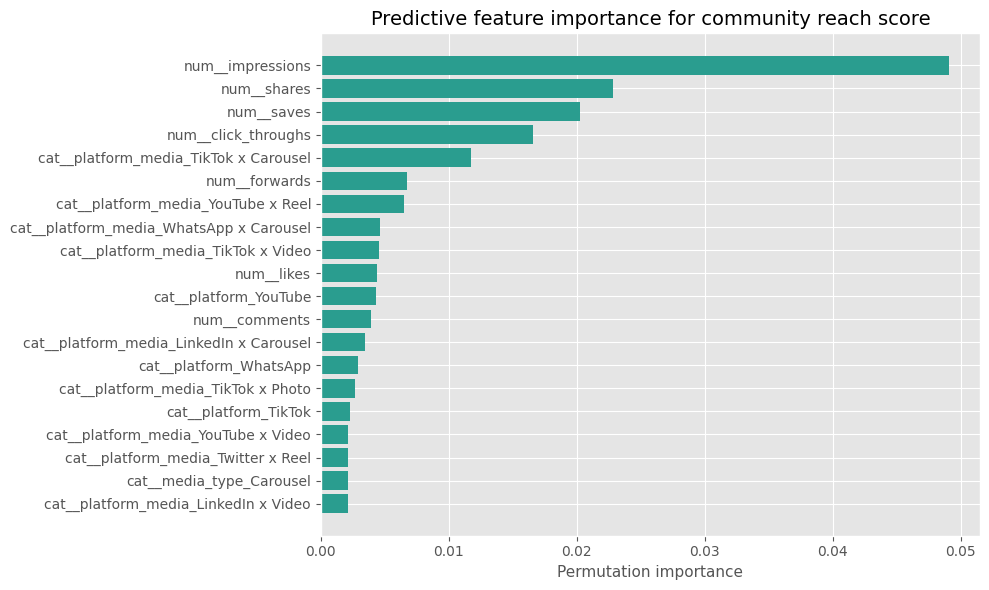

In [6]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
fitted_estimator = best_model.named_steps["model"]
if hasattr(fitted_estimator, "feature_importances_"):
    raw_importance = fitted_estimator.feature_importances_
else:
    raw_importance = np.abs(np.ravel(fitted_estimator.coef_))
importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": raw_importance,
        }
    )
    .sort_values("importance", ascending=False)
    .head(20)
)
display(importance_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importance_df["feature"].iloc[::-1],
    importance_df["importance"].iloc[::-1],
    color="#2a9d8f",
)
ax.set_title("Predictive feature importance for community reach score")
ax.set_xlabel("Permutation importance")
plt.tight_layout()
plt.show()


**Executive Takeaway.** The modeling stage intentionally uses two lenses. OLS explains strategic relationships in a way staff can discuss. The tree-based models handle nonlinear prediction better and are more appropriate for an Outreach-tab optimizer that estimates likely future performance.


# 4. Evaluation & Interpretation

The case PDF asks for proper validation and business interpretation, not just model scores. This section compares holdout and cross-validation performance, then translates the numbers into realistic outreach decisions.


,actual,predicted,residual
551,0.042055,0.037382,0.004673
672,0.017805,0.016001,0.001805
168,0.003551,0.001601,0.001950
473,0.051690,0.060450,-0.008760
77,0.178494,0.166520,0.011974


,Model,RMSE,MAE,R2,CV_RMSE,CV_MAE,CV_R2
0,LinearRegression,0.0091,0.0053,0.9944,0.0071,0.0047,0.9958
2,GradientBoostingRegressor,0.0147,0.0073,0.9854,0.0165,0.0074,0.9770
1,RandomForestRegressor,0.0182,0.0090,0.9774,0.0179,0.0084,0.9725


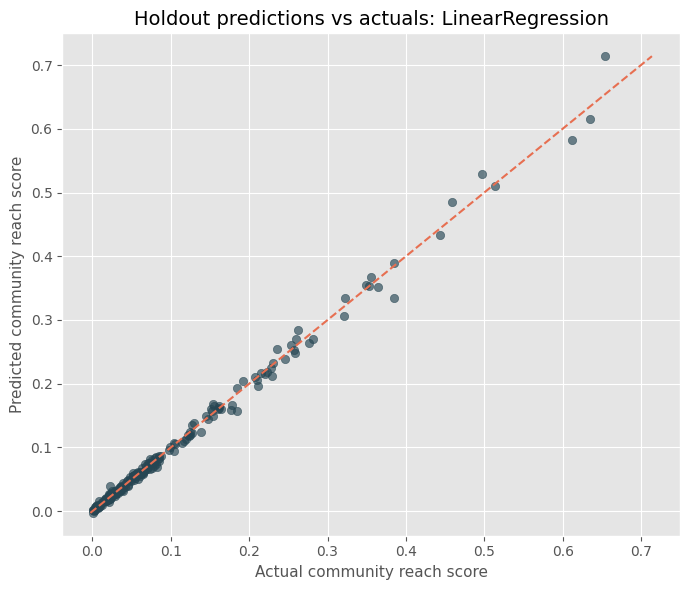

,platform,media_type,time_bucket,features_resident_story,avg_score,avg_reach,avg_share_rate,posts
97,TikTok,Reel,evening,False,0.2526,9169.0909,0.0280,22
177,YouTube,Video,afternoon,False,0.2143,8428.3462,0.0264,26
95,TikTok,Reel,afternoon,False,0.1776,7776.0000,0.0147,14
34,Instagram,Carousel,afternoon,False,0.1435,5154.8333,0.0207,12
42,Instagram,Photo,afternoon,False,0.1108,4322.2857,0.0234,14
29,Facebook,Video,evening,False,0.1103,4363.0000,0.0214,19
9,Facebook,Photo,evening,False,0.1082,4384.5714,0.0191,21
60,Instagram,Video,afternoon,False,0.1055,3867.0000,0.0235,12
36,Instagram,Carousel,evening,False,0.1010,3656.8182,0.0290,11
46,Instagram,Photo,morning,False,0.0927,3814.8462,0.0210,13


In [7]:
holdout_predictions = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": best_model.predict(X_test),
    }
)
holdout_predictions["residual"] = holdout_predictions["actual"] - holdout_predictions["predicted"]
display(holdout_predictions.head())

evaluation_table = results_table[["Model", "RMSE", "MAE", "R2", "CV_RMSE", "CV_MAE", "CV_R2"]].copy()
display(evaluation_table.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(holdout_predictions["actual"], holdout_predictions["predicted"], alpha=0.65, color="#264653")
min_edge = float(min(holdout_predictions["actual"].min(), holdout_predictions["predicted"].min()))
max_edge = float(max(holdout_predictions["actual"].max(), holdout_predictions["predicted"].max()))
ax.plot([min_edge, max_edge], [min_edge, max_edge], linestyle="--", color="#e76f51")
ax.set_title(f"Holdout predictions vs actuals: {best_model_name}")
ax.set_xlabel("Actual community reach score")
ax.set_ylabel("Predicted community reach score")
plt.tight_layout()
plt.show()

top_strategy_rows = posts.groupby(["platform", "media_type", "time_bucket", "features_resident_story"]).agg(
    avg_score=("community_reach_score", "mean"),
    avg_reach=("reach", "mean"),
    avg_share_rate=("share_rate", "mean"),
    posts=("community_reach_score", "size"),
).reset_index().query("posts >= 10").sort_values("avg_score", ascending=False).head(10)
display(top_strategy_rows.round(4))


**Business interpretation.**
- Lower RMSE and MAE mean the model is making smaller score errors when estimating expected post performance.
- A higher R^2 means the model is explaining more of the variation in outreach performance across posts.
- The output is best used for ranking options, not claiming exact reach counts.

**Business recommendations.**
- Prioritize platform-format combinations that consistently rank near the top in average `community_reach_score`.
- Treat resident-story content and strong sharing behavior as mission-aligned outreach signals, not just engagement bait.
- Use boosting selectively: if it raises reach but not sharing or forwarding, it may expand exposure without improving community spread.
- Time-of-day patterns should be used as defaults in the Outreach tab, but they should be layered with content type and platform.

**Executive Takeaway.** A moderately strong model is still useful if it helps the staff choose among several content options before posting. The right business outcome is better prioritization, not false confidence.


# 5. Causal and Relationship Analysis

The IS 455 PDF explicitly warns against confusing prediction with explanation. This section separates what appears useful for strategy from what would require stronger causal evidence.

**Likely influential relationships to discuss.**
- Platform and media combinations often capture structural differences in how audiences consume content.
- Resident-story content may increase community response because it makes the mission concrete and emotionally legible.
- CTA usage may improve click-throughs but not always broader awareness if the message feels transactional.
- Boosting may improve top-of-funnel visibility while leaving sharing behavior unchanged or uneven.

**Correlation is not causation.**
- Strong performance for a platform does not prove the platform itself causes better awareness; better creative work could be disproportionately posted there.
- Resident-story content may be chosen for stronger campaigns, so its estimated effect could partly reflect selection bias.
- Higher reach may itself make shares and saves more likely, so some metrics move together for mechanical reasons.

**Potential strategic insight without overclaiming.**
- If story-driven posts repeatedly outperform across multiple slices, that is enough to justify more experimentation with story-centered content.
- If certain time buckets underperform consistently, the outreach team can change scheduling policy even without proving deep causality.
- If certain platforms produce strong donation value but weaker community spread, leadership can distinguish donor conversion strategy from awareness strategy.


In [8]:
relationship_table = pd.DataFrame(
    {
        "Top OLS coefficient features": top_positive_coefficients["feature"].head(8),
        "Approximate coefficient": top_positive_coefficients["coefficient"].head(8),
    }
)
display(relationship_table)

practical_relationships = pd.DataFrame(
    {
        "finding": [
            "Highest-average platform",
            "Highest-average post type",
            "Best time bucket",
            "Boosted vs organic score gap",
        ],
        "evidence": [
            platform_summary.index[0] if len(platform_summary) else "N/A",
            content_summary.index[0] if len(content_summary) else "N/A",
            time_summary["avg_score"].idxmax() if len(time_summary) else "N/A",
            float(boost_summary.loc["Boosted", "avg_score"] - boost_summary.loc["Organic", "avg_score"]) if {"Boosted", "Organic"}.issubset(boost_summary.index) else np.nan,
        ],
    }
)
display(practical_relationships)


,Top OLS coefficient features,Approximate coefficient
0,platform_media_YouTube x Reel,0.085505
1,platform_YouTube,0.076711
2,is_boosted,0.054865
3,platform_media_TikTok x Carousel,0.041938
4,features_resident_story,0.033556
5,platform_media_TikTok x Reel,0.030073
6,story_cta_combo_story_no_cta,0.028402
7,platform_media_Instagram x Video,0.027041


,finding,evidence
0,Highest-average platform,YouTube
1,Highest-average post type,ImpactStory
2,Best time bucket,afternoon
3,Boosted vs organic score gap,0.131397


**Executive Takeaway.** The best use of this analysis is not to make sweeping causal claims. It is to support smarter experimentation in the Outreach tab: better default platform choices, better time choices, more intentional CTA usage, and more mission-aligned creative planning.


# 6. Deployment Notes

**Website integration target.** This pipeline should power a `Community Outreach Intelligence` workflow inside the Outreach tab.

**Recommended UI outputs.**
- best outreach platform
- best posting time bucket
- predicted `community_reach_score`
- predicted community-referral potential proxy
- predicted share rate
- top strategic drivers such as resident story usage, CTA use, boosting, and media choice
- platform-specific media guidance so staff can compare formats such as reels, videos, photos, and carousels on each channel

**How the feature should work.**
1. Staff opens a live planner from the Outreach tab and enters a planned post configuration.
2. The API scores the planned post with the predictive model and updates the outputs live as fields change.
3. The UI returns a compact planning view with predicted awareness performance plus a deeper strategy dialog.
4. The strategy dialog lets staff switch platforms and toggle key features such as resident story, CTA, `ImpactStory`, and boosted status to see how the best media type changes.
5. Staff uses the explanatory summaries to understand why the recommendation is appearing, then uses the predictive score to choose what to publish next.

**Recommended website behavior.**
- A header-level `Open live planner` action should launch a popup instead of forcing staff to scroll through a long inline form.
- The planner should update predicted outreach performance in real time as staff changes the platform, media type, CTA, resident-story flag, and posting window.
- A clickable `What To Post Next` summary should open a strategy view with platform chips and feature toggles so staff can explore how media recommendations change under different assumptions.
- The admin workflow should keep this planner separate from donation optimization so awareness-first and fundraising-first decisions are not conflated.

**Suggested API response.**



In [9]:
example_response = {
    "postOptimizer": {
        "bestPlatform": str(platform_summary.index[0]) if len(platform_summary) else None,
        "bestTimeBucket": str(time_summary["avg_score"].idxmax()) if len(time_summary) else None,
        "predictedCommunityReachScore": round(float(best_model.predict(X_test.iloc[[0]])[0]), 4),
        "predictedReferralPotential": round(float(posts["likely_community_referral"].mean()), 4),
        "topDrivers": importance_df.head(5).to_dict(orient="records"),
        "notes": [
            "Use this score to rank post ideas before publishing.",
            "Resident-story content and share-friendly formats often align with stronger community spread.",
            "This is decision support, not a guarantee of reach."
        ],
    }
}
display(JSON(example_response))


<IPython.core.display.JSON object>

**Deployment guidance tied to the case PDF.**
- This feature directly addresses the PDF's social-media questions: what to post, what platform to use, what time to post, and what content works.
- It belongs in the admin Outreach tab, not the donor dashboard.
- Leadership should view aggregate strategy summaries, while outreach staff should use the live planner and platform-media strategy view for day-to-day execution.
- The live planner supports the predictive requirement, while the strategy dialog and explanation cards support the explanatory requirement.

**Final Executive Takeaway.** This notebook now maps directly to the deployed website behavior: a live outreach planner, a clickable strategy summary, platform-specific media guidance, and interpretable planning cues that help staff improve mission-facing outreach without overclaiming causality.

